# Green Hydrogen Production with Time-Varying Power

This notebook models a **PEM water electrolyzer** fed by a **variable renewable power source** (combined solar + wind over 24 h) using NeqSim's `Electrolyzer` and `ElectrolyzerIVCharacteristic` classes.

## Native power-driven operation

The `Electrolyzer` now supports a **power-driven mode**: instead of giving it a water feed rate, you give it the available electrical power $P(t)$ and it solves the inverse problem internally.

$$P_{stack} = j \cdot A_{stack} \cdot V_{cell}(j, T)$$

NeqSim inverts this non-linear balance for the current density $j$ (the cell voltage $V_{cell}(j,T)$ comes from the attached I-V / polarisation model), then computes the hydrogen, oxygen and water flows. The full operating envelope is handled in Java:

- **`setAvailablePower(P)`** — switches to power-driven mode and sizes the operating point from the available power.
- **`sizeStack(ratedPower)`** — derives the stack active area from a rated point, so current density follows load.
- **`setMinimumLoadFraction` / `isStandby()`** — minimum turndown and standby (no production below the floor).
- **`getCurtailedPower()`** — excess power above rated is curtailed automatically.
- **`setRectifierEfficiency` / `setAuxiliaryLoadFraction`** — balance-of-plant losses → *system* vs *stack* efficiency.
- **`getWasteHeat()` / `getWaterConsumption(...)`** — stack thermal load and stoichiometric water demand.
- **`setMaxRampRate` + `runTransient(dt, id)`** — ramp-rate-limited transient response to a changing power signal.
- **`setHydrogenDeliveryPressure` / `getHydrogenCompressionPower()`** — pressurised delivery and ideal compression duty.

This notebook drives the renewable supply profile straight into `setAvailablePower(...)` — no Python-side inversion, standby filtering, or curtailment bookkeeping required.


In [ ]:
# --- NeqSim devtools setup: load Java classes from the workspace target/classes ---
import os
import sys
from pathlib import Path


def find_neqsim_project_root():
    env_root = os.environ.get("NEQSIM_PROJECT_ROOT")
    candidates = []
    if env_root:
        candidates.append(Path(env_root).resolve())
    cwd = Path.cwd().resolve()
    candidates.extend([cwd] + list(cwd.parents))
    for candidate in candidates:
        if (candidate / "pom.xml").exists() and (candidate / "devtools" / "neqsim_dev_setup.py").exists():
            return candidate
    raise RuntimeError("Could not find NeqSim project root. Set NEQSIM_PROJECT_ROOT.")


PROJECT_ROOT = find_neqsim_project_root()
sys.path.insert(0, str(PROJECT_ROOT / "devtools"))

from neqsim_dev_setup import neqsim_init, neqsim_classes

ns = neqsim_init(project_root=PROJECT_ROOT, recompile=False, verbose=True)
ns = neqsim_classes(ns)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("NeqSim ready.")

NeqSim project root: C:\Users\ESOL\Documents\GitHub\neqsim
Classpath:
  1. C:\Users\ESOL\Documents\GitHub\neqsim\target\classes
  2. C:\Users\ESOL\Documents\GitHub\neqsim\src\main\resources
  3. C:\Users\ESOL\Documents\GitHub\neqsim\target\neqsim-3.13.0.jar



JVM started: C:\Users\ESOL\graalvm\graalvm-jdk-25.0.1+8.1\bin\server\jvm.dll
Ready — call neqsim_classes(ns) to import classes


All NeqSim classes imported OK


NeqSim ready.


## 1. Build the PEM electrolyzer in NeqSim

We create a water feed stream and a PEM `Electrolyzer`, attach a physics-based I-V (polarisation) characteristic, and size the stack from a nominal (rated) operating point.

In [ ]:
# Electrolyzer classes
Electrolyzer = ns.JClass("neqsim.process.equipment.electrolyzer.Electrolyzer")
ElectrolyzerTechnology = ns.JClass("neqsim.process.equipment.electrolyzer.ElectrolyzerTechnology")
ElectrolyzerIVCharacteristic = ns.JClass(
    "neqsim.process.equipment.electrolyzer.ElectrolyzerIVCharacteristic"
)

# --- Operating conditions ---
T_C = 80.0           # stack temperature [C]
T_K = T_C + 273.15
P_BARA = 30.0        # stack/delivery pressure [bara]
MW_H2 = 0.002016     # kg/mol
MW_O2 = 0.031998     # kg/mol

# --- Stack sizing and operating envelope ---
P_NOM_MW = 10.0                 # rated stack power [MW]
P_NOM = P_NOM_MW * 1.0e6        # [W]
J_NOM = 2.0                     # nominal current density [A/cm2] (PEM)
MIN_LOAD_FRACTION = 0.10        # below 10% of rated -> standby (no H2)
STANDBY_FRACTION = 0.01         # idle auxiliary draw while in standby
RECTIFIER_EFF = 0.96            # AC/DC rectifier efficiency
AUX_LOAD_FRACTION = 0.04        # pumps + thermal management, fraction of stack power
FARADAIC_EFF = 0.98

# --- Water feed stream ---
water = ns.SystemSrkEos(T_K, P_BARA)
water.addComponent("water", 1.0)
water.setMixingRule("classic")

water_feed = ns.Stream("water feed", water)
water_feed.setFlowRate(1.0, "mole/sec")
water_feed.setTemperature(T_K, "K")
water_feed.setPressure(P_BARA, "bara")
water_feed.run()

# --- PEM electrolyzer in native power-driven mode ---
electro = Electrolyzer("PEM electrolyzer", water_feed)
electro.setTechnology(ElectrolyzerTechnology.PEM)   # 1.8 V, 2.0 A/cm2, 80 C
electro.setFaradaicEfficiency(FARADAIC_EFF)

iv = ElectrolyzerIVCharacteristic(ElectrolyzerTechnology.PEM)
electro.setIVCharacteristic(iv)

# NIP-2: size the stack from the rated point -> current density now follows load
electro.sizeStack(P_NOM, J_NOM, T_K)
# NIP-3: minimum turndown / standby
electro.setMinimumLoadFraction(MIN_LOAD_FRACTION)
electro.setStandbyPowerFraction(STANDBY_FRACTION)
# NIP-5: balance-of-plant losses -> system vs stack efficiency
electro.setRectifierEfficiency(RECTIFIER_EFF)
electro.setAuxiliaryLoadFraction(AUX_LOAD_FRACTION)
# NIP-7: deliver hydrogen at the stack pressure (compression power available on demand)
electro.setHydrogenDeliveryPressure(P_BARA)

process = ns.ProcessSystem()
process.add(water_feed)
process.add(electro)

V_NOM = float(iv.getCellVoltage(J_NOM, T_K))
A_STACK = float(electro.getStackActiveArea())   # cm2, derived by sizeStack

print(f"Nominal cell voltage at j={J_NOM} A/cm2, {T_C} C : {V_NOM:.3f} V")
print(f"Total stack active area (sizeStack)  : {A_STACK/1e4:,.0f} m^2")
print(f"Rated power                          : {P_NOM_MW:.1f} MW")
print(f"Minimum operating power (standby)    : {MIN_LOAD_FRACTION*P_NOM_MW:.1f} MW")


Nominal cell voltage at j=2.0 A/cm2, 80.0 C : 1.740 V
Total stack active area              : 287 m^2
Rated power                          : 10.0 MW
Minimum operating power (standby)    : 1.0 MW


## 2. Define the time-varying renewable power profile

A synthetic 24-hour profile (hourly) combining a solar bell curve with a fluctuating wind component. The peak available power deliberately exceeds the rated stack power so we can show **curtailment**, and the night periods drop below the minimum load so we can show **standby**.

In [ ]:
rng = np.random.default_rng(42)
hours = np.arange(0, 24)

# Solar: bell centred at 13:00, zero at night
solar = np.maximum(0.0, np.sin((hours - 6.0) / 12.0 * np.pi)) ** 2
solar_mw = 9.0 * solar

# Wind: slowly varying base + gusts
wind_base = 3.5 + 2.0 * np.sin((hours / 24.0) * 2 * np.pi + 1.0)
wind_gust = rng.normal(0.0, 1.0, size=hours.size)
wind_mw = np.clip(wind_base + wind_gust, 0.0, None)

available_mw = solar_mw + wind_mw   # total renewable supply [MW]

power_df = pd.DataFrame({
    "hour": hours,
    "solar_MW": solar_mw.round(2),
    "wind_MW": wind_mw.round(2),
    "available_MW": available_mw.round(2),
})
power_df

,hour,solar_MW,wind_MW,available_MW
0,0,0.00,5.49,5.49
1,1,0.00,4.37,4.37
2,2,0.00,6.25,6.25
3,3,0.00,6.39,6.39
4,4,0.00,3.33,3.33
5,5,0.00,3.68,3.68
6,6,0.00,4.71,4.71
7,7,0.60,3.79,4.39
8,8,2.25,3.58,5.83
9,9,4.50,2.22,6.72


## 3. Native power-driven run

For each hour we hand the available renewable power straight to the electrolyzer with `setAvailablePower(...)` and call `process.run()`. NeqSim then:

1. converts the **system (AC)** power budget to a **stack (DC)** power using the rectifier/auxiliary losses,
2. inverts $P_{stack} = j \cdot A_{stack} \cdot V_{cell}(j, T)$ for the current density (the I-V physics),
3. applies the **minimum turndown** (standby below the floor) and **curtailment** above rated power,
4. produces the H₂/O₂ streams and reports water demand, waste heat and efficiencies.

All of the inversion, standby and curtailment logic now lives in Java — the Python loop only reads results back.


In [ ]:
rows = []
for h, p_avail_mw in zip(hours, available_mw):
    # NIP-1: hand the available (system, AC) power to NeqSim; it solves the rest.
    electro.setAvailablePower(p_avail_mw * 1.0e6)
    process.run()

    standby = bool(electro.isStandby())
    h2_kg_h = float(electro.getHydrogenOutStream().getFlowRate("mole/sec")) * MW_H2 * 3600.0
    o2_kg_h = float(electro.getOxygenOutStream().getFlowRate("mole/sec")) * MW_O2 * 3600.0
    water_kg_h = float(electro.getWaterConsumption("kg/hr"))
    system_mw = float(electro.getSystemPower()) / 1.0e6
    curtailed_mw = float(electro.getCurtailedPower()) / 1.0e6
    waste_heat_mw = float(electro.getWasteHeat()) / 1.0e6
    j = float(electro.getCurrentDensity())
    v = float(electro.getCellVoltage())
    sec_system = float(electro.getSystemSpecificEnergyConsumption_kWh_per_kg_H2())

    rows.append({
        "hour": int(h), "available_MW": float(p_avail_mw),
        "used_MW": system_mw, "curtailed_MW": curtailed_mw,
        "j_A_cm2": j, "V_cell": (np.nan if standby else v),
        "H2_kg_h": h2_kg_h, "O2_kg_h": o2_kg_h, "water_kg_h": water_kg_h,
        "waste_heat_MW": waste_heat_mw,
        "SEC_kWh_per_kg": (np.nan if h2_kg_h <= 0 else sec_system),
        "state": "standby" if standby else "running",
    })

results = pd.DataFrame(rows)
results.round(3)


,hour,available_MW,used_MW,curtailed_MW,j_A_cm2,V_cell,H2_kg_h,O2_kg_h,water_kg_h,SEC_kWh_per_kg,state
0,0,5.488,5.488,0.000,1.206,1.584,130.284,1033.936,1187.980,42.121,running
1,1,4.365,4.365,0.000,0.987,1.540,106.640,846.298,972.386,40.935,running
2,2,6.248,6.248,0.000,1.348,1.613,145.709,1156.350,1328.632,42.881,running
3,3,6.395,6.395,0.000,1.375,1.618,148.629,1179.521,1355.255,43.025,running
4,4,3.326,3.326,0.000,0.774,1.495,83.680,664.086,763.027,39.750,running
5,5,3.677,3.677,0.000,0.847,1.510,91.561,726.625,834.884,40.161,running
6,6,4.708,4.708,0.000,1.055,1.554,113.988,904.613,1039.389,41.306,running
7,7,4.395,4.395,0.000,0.993,1.541,107.278,851.356,978.197,40.967,running
8,8,5.828,5.828,0.000,1.270,1.597,137.234,1089.087,1251.348,42.465,running
9,9,6.721,6.721,0.000,1.435,1.630,155.078,1230.704,1414.064,43.340,running


## 4. Daily summary and closure check

In [ ]:
total_h2 = results["H2_kg_h"].sum()           # kg over 24 h (hourly steps)
total_o2 = results["O2_kg_h"].sum()
total_water = results["water_kg_h"].sum()
energy_used = results["used_MW"].sum()        # MWh over 24 h (system / AC)
energy_available = results["available_MW"].sum()
energy_curtailed = results["curtailed_MW"].sum()
avg_sec = energy_used * 1000.0 / total_h2 if total_h2 > 0 else float("nan")
standby_hours = int((results["state"] == "standby").sum())

print(f"Total H2 produced            : {total_h2:,.0f} kg/day")
print(f"Total O2 by-product          : {total_o2:,.0f} kg/day")
print(f"Total water consumed         : {total_water:,.0f} kg/day")
print(f"Energy available             : {energy_available:,.1f} MWh/day")
print(f"Energy used (system/AC)      : {energy_used:,.1f} MWh/day")
print(f"Energy curtailed             : {energy_curtailed:,.1f} MWh/day "
      f"({100*energy_curtailed/energy_available:.1f}% of available)")
print(f"Hours in standby             : {standby_hours} h")
print(f"Average system specific use  : {avg_sec:.1f} kWh/kg H2 (incl. balance-of-plant)")

# Mass-balance closure: stoichiometric water_in == H2_out + O2_out (per running hour)
run = results[results["state"] == "running"]
closure_err = (run["water_kg_h"] - (run["H2_kg_h"] + run["O2_kg_h"])).abs()
rel = closure_err / run["water_kg_h"].replace(0, np.nan)
print(f"\nMax mass-balance error       : {rel.max()*100:.3f}% "
      "(NeqSim getWaterConsumption is exact stoichiometric H2O -> H2 + 1/2 O2)")


Total H2 produced            : 3,118 kg/day
Total O2 by-product          : 24,743 kg/day
Total water consumed         : 28,429 kg/day
Energy available             : 137.5 MWh/day
Energy used by stack         : 134.0 MWh/day
Energy curtailed             : 3.5 MWh/day (2.6% of available)
Hours in standby             : 0 h
Average specific energy use  : 43.0 kWh/kg H2

Max mass-balance error       : 2.00% (small gap = water not fully converted at eta_F < 1)


## 5. Visualisation

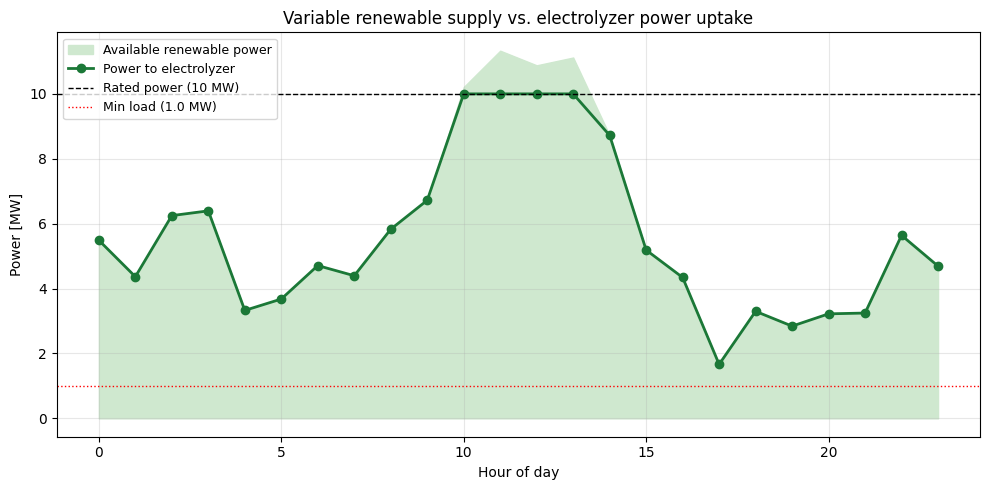

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.fill_between(power_df["hour"], 0, power_df["available_MW"], color="#cfe8cf",
                label="Available renewable power")
ax.plot(results["hour"], results["used_MW"], color="#1b7837", lw=2, marker="o",
        label="Power to electrolyzer")
ax.axhline(P_NOM_MW, color="k", ls="--", lw=1, label=f"Rated power ({P_NOM_MW:.0f} MW)")
ax.axhline(MIN_LOAD_FRACTION * P_NOM_MW, color="red", ls=":", lw=1,
           label=f"Min load ({MIN_LOAD_FRACTION*P_NOM_MW:.1f} MW)")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Power [MW]")
ax.set_title("Variable renewable supply vs. electrolyzer power uptake")
ax.legend(loc="upper left", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

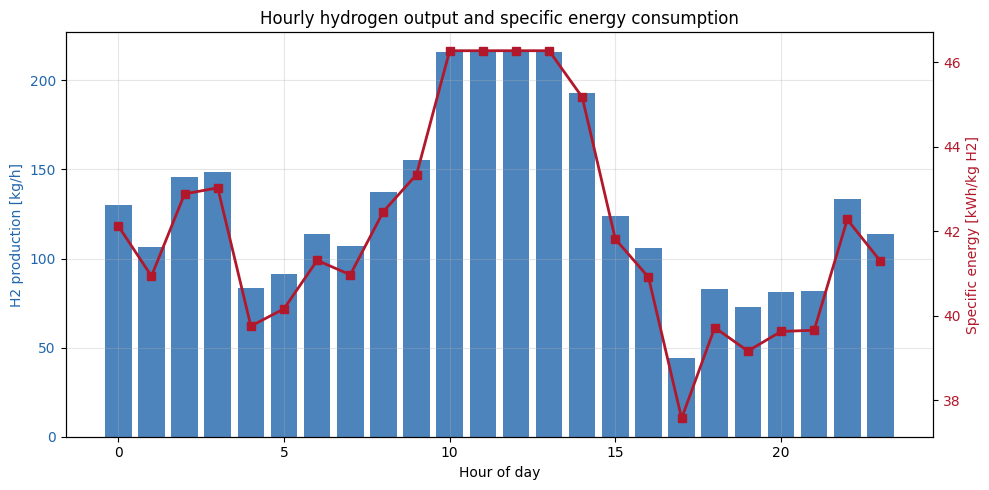

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(results["hour"], results["H2_kg_h"], color="#2166ac", alpha=0.8, label="H2 production")
ax1.set_xlabel("Hour of day")
ax1.set_ylabel("H2 production [kg/h]", color="#2166ac")
ax1.tick_params(axis="y", labelcolor="#2166ac")
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(results["hour"], results["SEC_kWh_per_kg"], color="#b2182b", lw=2, marker="s",
         label="Specific energy use")
ax2.set_ylabel("Specific energy [kWh/kg H2]", color="#b2182b")
ax2.tick_params(axis="y", labelcolor="#b2182b")
ax1.set_title("Hourly hydrogen output and specific energy consumption")
fig.tight_layout()
plt.show()

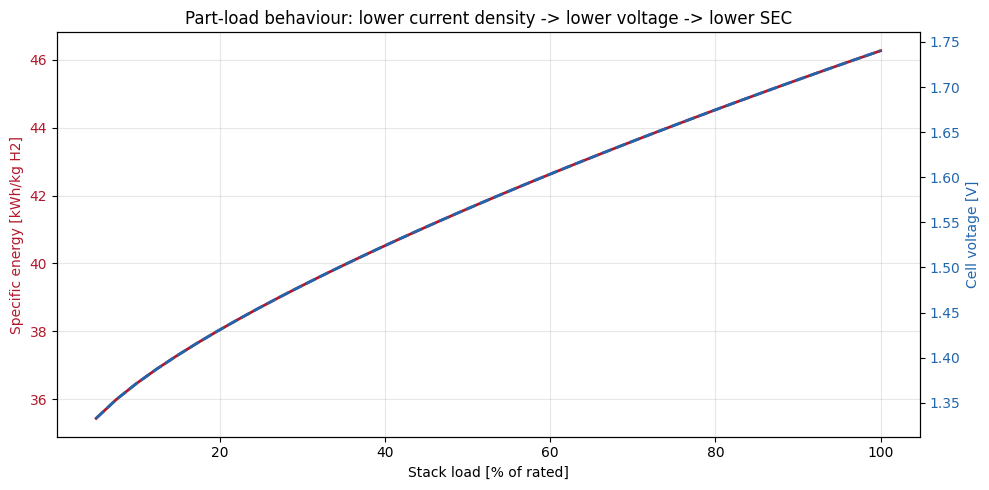

In [ ]:
# Part-load efficiency curve driven natively: sweep available power, read stack load & SEC.
# Electrolyzers are MORE efficient at part load (lower current density -> lower voltage).
rated_system = float(electro.getSystemPower())  # placeholder; recomputed below at full load
electro.setAvailablePower(P_NOM)                 # full load (system budget ~ rated stack)
process.run()
rated_system = float(electro.getSystemPower())

loads = np.linspace(MIN_LOAD_FRACTION, 1.0, 40)
load_pct, sec_curve, v_curve = [], [], []
for lf in loads:
    electro.setAvailablePower(lf * rated_system)
    process.run()
    if electro.isStandby():
        continue
    stack_load_pct = 100.0 * float(electro.getStackPower()) / P_NOM
    load_pct.append(stack_load_pct)
    sec_curve.append(float(electro.getSystemSpecificEnergyConsumption_kWh_per_kg_H2()))
    v_curve.append(float(electro.getCellVoltage()))

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(load_pct, sec_curve, color="#b2182b", lw=2)
ax1.set_xlabel("Stack load [% of rated]")
ax1.set_ylabel("System specific energy [kWh/kg H2]", color="#b2182b")
ax1.tick_params(axis="y", labelcolor="#b2182b")
ax1.grid(alpha=0.3)
ax2 = ax1.twinx()
ax2.plot(load_pct, v_curve, color="#2166ac", lw=2, ls="--")
ax2.set_ylabel("Cell voltage [V]", color="#2166ac")
ax2.tick_params(axis="y", labelcolor="#2166ac")
ax1.set_title("Part-load behaviour: lower current density -> lower voltage -> lower SEC")
fig.tight_layout()
plt.show()


## 6. Ramp-rate-limited transient response

Real stacks cannot follow instantaneous power steps. With `setMaxRampRate(...)` and
`runTransient(dt, id)` the electrolyzer ramps toward the commanded power at a bounded rate
(fraction of rated power per second), starting cold from zero. Here we command a step to full
power and integrate at 1-second resolution to watch the stack ramp up.


In [ ]:
from java.util import UUID

# NIP-4: ramp-rate limiting at 5% of rated power per second.
electro.setMaxRampRate(0.05)          # -> reaches 100% in ~20 s from cold start
electro.setCalculateSteadyState(False)
electro.setAvailablePower(P_NOM)      # command a step to full power
electro.setOperationMode(electro.getOperationMode())  # ensure POWER mode retained

run_id = UUID.randomUUID()
t, op_mw, h2_kg_h_t = [], [], []
for step in range(31):                # 30 seconds at dt = 1 s
    electro.runTransient(1.0, run_id)
    t.append(step)
    op_mw.append(float(electro.getOperatingPower()) / 1.0e6)
    h2_kg_h_t.append(
        float(electro.getHydrogenOutStream().getFlowRate("mole/sec")) * MW_H2 * 3600.0
    )

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(t, op_mw, color="#1b7837", lw=2, marker="o", label="Operating power")
ax1.axhline(P_NOM_MW, color="k", ls="--", lw=1, label=f"Commanded ({P_NOM_MW:.0f} MW)")
ax1.set_xlabel("Time after step [s]")
ax1.set_ylabel("Power [MW]", color="#1b7837")
ax1.tick_params(axis="y", labelcolor="#1b7837")
ax1.grid(alpha=0.3)
ax2 = ax1.twinx()
ax2.plot(t, h2_kg_h_t, color="#2166ac", lw=2, label="H2 production")
ax2.set_ylabel("H2 production [kg/h]", color="#2166ac")
ax2.tick_params(axis="y", labelcolor="#2166ac")
ax1.set_title("Ramp-rate-limited start-up (5%/s): power and H2 follow the ramp")
ax1.legend(loc="lower right", fontsize=9)
fig.tight_layout()
plt.show()

print(f"Reached {op_mw[-1]:.2f} MW of {P_NOM_MW:.0f} MW after {t[-1]} s "
      f"at {electro.getMaxRampRate()*100:.0f}%/s ramp limit")


## 7. Summary — fully native

The entire transient green-hydrogen calculation now runs inside NeqSim's `Electrolyzer`:

| Capability | Native method |
|------------|---------------|
| Power-driven operating point | `setAvailablePower(P)` (inverts $P = j\,A\,V_{cell}(j,T)$) |
| Stack sizing from rated point | `sizeStack(ratedPower, j_nom, T)` |
| Minimum turndown / standby | `setMinimumLoadFraction`, `isStandby()` |
| Curtailment above rated | `getCurtailedPower()` |
| Balance-of-plant losses | `setRectifierEfficiency`, `setAuxiliaryLoadFraction`, `getSystemPower`, `getSystemSpecificEnergyConsumption_kWh_per_kg_H2` |
| Thermal load & water demand | `getWasteHeat()`, `getWaterConsumption(unit)` |
| Ramp-rate-limited transient | `setMaxRampRate`, `runTransient(dt, id)`, `getOperatingPower()` |
| Pressurised delivery / compression | `setHydrogenDeliveryPressure`, `getHydrogenCompressionPower()` |

The Python side only supplies the renewable power profile and reads results back — no inversion,
standby filtering, or curtailment bookkeeping is done outside NeqSim.
